In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
saitosean_mercari_path = kagglehub.dataset_download('saitosean/mercari')

print('Data source import complete.')


Using Colab cache for faster access to the 'mercari' dataset.
Data source import complete.


# 0. Boilerplate Setup

In [2]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [3]:
train = pd.read_csv(
    os.path.join(saitosean_mercari_path, "train.tsv"),
    sep="\t",
    dtype={
        "train_id": "int32",
        "item_condition_id": "int8",
        "shipping": "int8"
    }
)

test = pd.read_csv(
    os.path.join(saitosean_mercari_path, "test.tsv"),
    sep="\t",
    dtype={
        "test_id": "int32",
        "item_condition_id": "int8",
        "shipping": "int8"
    }
)

In [4]:
# import os
# os.listdir("/kaggle/input/datasets/saitosean")

# 1. Data Ingestion & Integrity

**1.1. Schema & Column Structure**

- Verify expected columns exist.
- Verify train/test column differences are intentional.
- Verify column ordering if relevant.

In [5]:
expected_train_columns = {
    "train_id",
    "name",
    "item_condition_id",
    "category_name",
    "brand_name",
    "price",
    "shipping",
    "item_description"
}

expected_test_columns = {
    "test_id",
    "name",
    "item_condition_id",
    "category_name",
    "brand_name",
    "shipping",
    "item_description"
}

print("TRAIN MISSING:", sorted(expected_train_columns - set(train.columns)))
print("TRAIN UNEXPECTED:", sorted(set(train.columns) - expected_train_columns))

print("TEST MISSING:", sorted(expected_test_columns - set(test.columns)))
print("TEST UNEXPECTED:", sorted(set(test.columns) - expected_test_columns))

print("TRAIN COLUMN ORDER:", list(train.columns))
print("TEST COLUMN ORDER:", list(test.columns))

TRAIN MISSING: []
TRAIN UNEXPECTED: []
TEST MISSING: []
TEST UNEXPECTED: []
TRAIN COLUMN ORDER: ['train_id', 'name', 'item_condition_id', 'category_name', 'brand_name', 'price', 'shipping', 'item_description']
TEST COLUMN ORDER: ['test_id', 'name', 'item_condition_id', 'category_name', 'brand_name', 'shipping', 'item_description']


**1.2. Data Type Enforcement**

- Check actual dtypes against expected dtypes.
- Identify unexpected type coercion or inference.

In [6]:
expected_train_dtypes = {
    "train_id": "int32",
    "name": "object",
    "item_condition_id": "int8",
    "category_name": "object",
    "brand_name": "object",
    "price": "float64",
    "shipping": "int8",
    "item_description": "object"
}

expected_test_dtypes = {
    "test_id": "int32",
    "name": "object",
    "item_condition_id": "int8",
    "category_name": "object",
    "brand_name": "object",
    "shipping": "int8",
    "item_description": "object"
}

train_dtype_check = pd.DataFrame({
    "actual": train.dtypes.astype(str),
    "expected": pd.Series(expected_train_dtypes)
})

train_dtype_check["match"] = (
    train_dtype_check["actual"] == train_dtype_check["expected"]
)

test_dtype_check = pd.DataFrame({
    "actual": test.dtypes.astype(str),
    "expected": pd.Series(expected_test_dtypes)
})

test_dtype_check["match"] = (
    test_dtype_check["actual"] == test_dtype_check["expected"]
)

print("TRAIN DTYPE CHECK")
print(train_dtype_check)

print("\nTEST DTYPE CHECK")
print(test_dtype_check)

TRAIN DTYPE CHECK
                    actual expected  match
train_id             int32    int32   True
name                object   object   True
item_condition_id     int8     int8   True
category_name       object   object   True
brand_name          object   object   True
price              float64  float64   True
shipping              int8     int8   True
item_description    object   object   True

TEST DTYPE CHECK
                   actual expected  match
test_id             int32    int32   True
name               object   object   True
item_condition_id    int8     int8   True
category_name      object   object   True
brand_name         object   object   True
shipping             int8     int8   True
item_description   object   object   True


**1.3. Null / Missing Value Audit**

- Count nulls per column.
- Identify unexpected nulls.

In [7]:
train_nulls = train.isna().sum()
test_nulls = test.isna().sum()

print("TRAIN NULLS")
print(train_nulls)

print("\nTEST NULLS")
print(test_nulls)

TRAIN NULLS
train_id                  0
name                      0
item_condition_id         0
category_name          6327
brand_name           632682
price                     0
shipping                  0
item_description          6
dtype: int64

TEST NULLS
test_id                   0
name                      0
item_condition_id         0
category_name          3058
brand_name           295525
shipping                  0
item_description          0
dtype: int64


***Note:** train: brand_name: 632682 null values, category_name: 6362 null values, item_description: 6 null values.test: brand_name: 295525 null values, category_name: 3058 bull values.significantly high null values in brand_name, much less but existant null values in category_name.*

**1.4. Duplicate Row Audit**
- Check for completely duplicated rows in train and test.

In [8]:
train_duplicate_rows = train.duplicated().sum()
test_duplicate_rows = test.duplicated().sum()

print("TRAIN DUPLICATE ROWS:", train_duplicate_rows)
print("TEST DUPLICATE ROWS:", test_duplicate_rows)

TRAIN DUPLICATE ROWS: 0
TEST DUPLICATE ROWS: 0


**1.5. Primary Key Integrity**

- Check train_id uniqueness.
- Check test_id uniqueness.
- Check for null primary keys.

In [9]:
print("TRAIN PRIMARY KEY")
print("Nulls:", train["train_id"].isna().sum())
print("Unique:", train["train_id"].is_unique)
print("Duplicate IDs:", train["train_id"].duplicated().sum())

print("\nTEST PRIMARY KEY")
print("Nulls:", test["test_id"].isna().sum())
print("Unique:", test["test_id"].is_unique)
print("Duplicate IDs:", test["test_id"].duplicated().sum())

TRAIN PRIMARY KEY
Nulls: 0
Unique: True
Duplicate IDs: 0

TEST PRIMARY KEY
Nulls: 0
Unique: True
Duplicate IDs: 0


**1.6. Basic Value Validity**

- Check whether constrained fields such as item_condition_id and shipping contain valid values.

In [10]:
print("ITEM CONDITION ID - TRAIN")
print(sorted(train["item_condition_id"].unique()))

print("\nITEM CONDITION ID - TEST")
print(sorted(test["item_condition_id"].unique()))

print("\nSHIPPING - TRAIN")
print(sorted(train["shipping"].unique()))

print("\nSHIPPING - TEST")
print(sorted(test["shipping"].unique()))

ITEM CONDITION ID - TRAIN
[np.int8(1), np.int8(2), np.int8(3), np.int8(4), np.int8(5)]

ITEM CONDITION ID - TEST
[np.int8(1), np.int8(2), np.int8(3), np.int8(4), np.int8(5)]

SHIPPING - TRAIN
[np.int8(0), np.int8(1)]

SHIPPING - TEST
[np.int8(0), np.int8(1)]


**1.7. Train–Test Structural Consistency**

- Compare shared feature columns.
- Confirm price exists only in train.
- Check for schema mismatches between corresponding columns.

In [11]:
train_features = [col for col in train.columns if col not in ["train_id", "price"]]
test_features = [col for col in test.columns if col != "test_id"]

print("SHARED FEATURES:", train_features == test_features)
print("TRAIN FEATURES:", train_features)
print("TEST FEATURES:", test_features)

print("\nTRAIN-ONLY COLUMNS:", sorted(set(train.columns) - set(test.columns)))
print("TEST-ONLY COLUMNS:", sorted(set(test.columns) - set(train.columns)))

SHARED FEATURES: True
TRAIN FEATURES: ['name', 'item_condition_id', 'category_name', 'brand_name', 'shipping', 'item_description']
TEST FEATURES: ['name', 'item_condition_id', 'category_name', 'brand_name', 'shipping', 'item_description']

TRAIN-ONLY COLUMNS: ['price', 'train_id']
TEST-ONLY COLUMNS: ['test_id']


# 2. Data Understanding & Validation

**2.1. Target Distribution**
- Inspect price distribution.
- Measure central tendency, spread, minimum/maximum.
- Measure skewness and kurtosis.
- Inspect log1p(price) distribution because evaluation uses RMSLE.
- Check for zero/near-zero target values and extreme outliers.

TARGET SUMMARY
              price   log1p_price
count  1.482535e+06  1.482535e+06
mean   2.673752e+01  2.979059e+00
std    3.858607e+01  7.492094e-01
min    0.000000e+00  0.000000e+00
25%    1.000000e+01  2.397895e+00
50%    1.700000e+01  2.890372e+00
75%    2.900000e+01  3.401197e+00
max    2.009000e+03  7.605890e+00

TARGET SKEWNESS
{'price': np.float64(11.393232000122524), 'log1p_price': np.float64(0.6594232018807694)}

TARGET KURTOSIS
{'price': np.float64(283.8216690879921), 'log1p_price': np.float64(1.089233237779847)}

TARGET VALIDITY
{'zero_prices': np.int64(874), 'negative_prices': np.int64(0), 'missing_prices': np.int64(0)}

TARGET PERCENTILES
0.00       0.0
0.01       3.0
0.05       6.0
0.25      10.0
0.50      17.0
0.75      29.0
0.95      75.0
0.99     170.0
1.00    2009.0
Name: price, dtype: float64


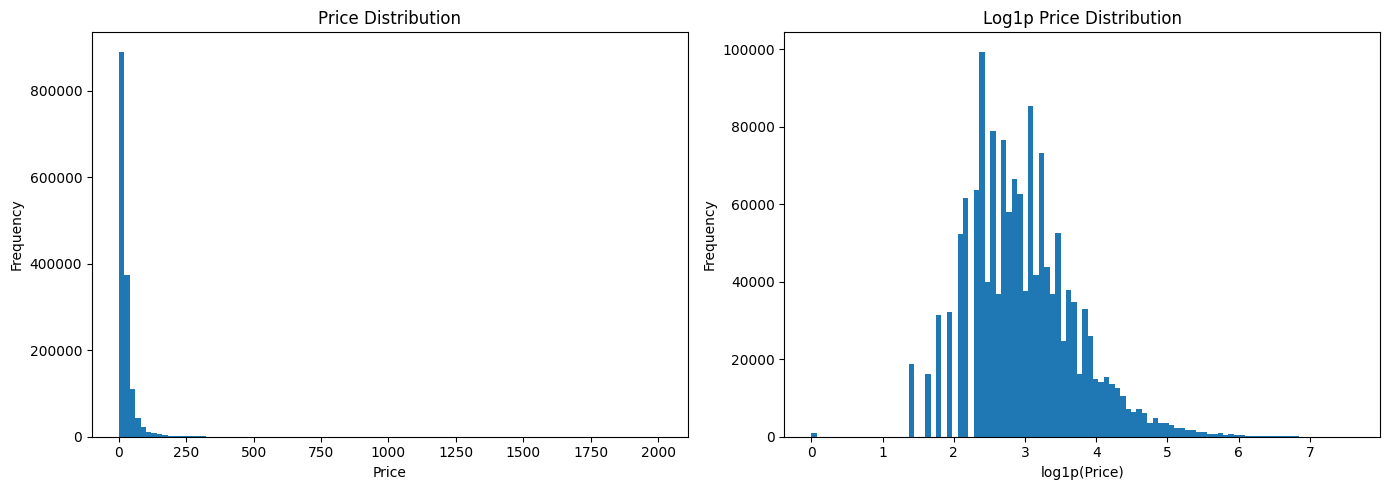

In [12]:
price = train["price"]
log_price = np.log1p(price)

target_summary = pd.DataFrame({
    "price": price.describe(),
    "log1p_price": log_price.describe()
})

print("TARGET SUMMARY")
print(target_summary)

print("\nTARGET SKEWNESS")
print({
    "price": price.skew(),
    "log1p_price": log_price.skew()
})

print("\nTARGET KURTOSIS")
print({
    "price": price.kurtosis(),
    "log1p_price": log_price.kurtosis()
})

print("\nTARGET VALIDITY")
print({
    "zero_prices": (price == 0).sum(),
    "negative_prices": (price < 0).sum(),
    "missing_prices": price.isna().sum()
})

print("\nTARGET PERCENTILES")
print(price.quantile([0, 0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99, 1.00]))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(price, bins=100)
axes[0].set_title("Price Distribution")
axes[0].set_xlabel("Price")
axes[0].set_ylabel("Frequency")

axes[1].hist(log_price, bins=100)
axes[1].set_title("Log1p Price Distribution")
axes[1].set_xlabel("log1p(Price)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

**2.2 Feature Distribution & Cardinality**

- Inspect unique-value counts for every feature.
- Measure categorical cardinality and missingness rates.
- Inspect frequency distributions of categorical variables.
- Inspect text length distributions for name and item_description.
- Identify rare categories / high-cardinality features.

In [13]:
features = [
    "name",
    "item_condition_id",
    "category_name",
    "brand_name",
    "shipping",
    "item_description"
]

feature_summary = pd.DataFrame({
    "dtype": train[features].dtypes.astype(str),
    "unique_train": train[features].nunique(dropna=False),
    "unique_test": test[features].nunique(dropna=False),
    "missing_train": train[features].isna().sum(),
    "missing_test": test[features].isna().sum()
})

feature_summary["missing_pct_train"] = (
    feature_summary["missing_train"] / len(train) * 100
)

feature_summary["missing_pct_test"] = (
    feature_summary["missing_test"] / len(test) * 100
)

print("FEATURE SUMMARY")
print(feature_summary)

print("\nTOP VALUES - CATEGORICAL FEATURES")

for column in ["item_condition_id", "shipping", "category_name", "brand_name"]:
    print(f"\n{column} - TRAIN")
    print(train[column].value_counts(dropna=False).head(10))

    print(f"{column} - TEST")
    print(test[column].value_counts(dropna=False).head(10))

text_summary = pd.DataFrame(index=["name", "item_description"])

for column in ["name", "item_description"]:
    train_length = train[column].fillna("").str.len()
    test_length = test[column].fillna("").str.len()

    text_summary.loc[column, "train_mean_length"] = train_length.mean()
    text_summary.loc[column, "train_median_length"] = train_length.median()
    text_summary.loc[column, "train_max_length"] = train_length.max()
    text_summary.loc[column, "test_mean_length"] = test_length.mean()
    text_summary.loc[column, "test_median_length"] = test_length.median()
    text_summary.loc[column, "test_max_length"] = test_length.max()

print("\nTEXT LENGTH SUMMARY")
print(text_summary)

print("\nRARE CATEGORY COUNTS")

for column in ["category_name", "brand_name"]:
    frequencies = train[column].value_counts(dropna=False)
    print(f"{column} frequency = 1:", (frequencies == 1).sum())
    print(f"{column} frequency <= 5:", (frequencies <= 5).sum())

FEATURE SUMMARY
                    dtype  unique_train  unique_test  missing_train  \
name               object       1225273       601117              0   
item_condition_id    int8             5            5              0   
category_name      object          1288         1224           6327   
brand_name         object          4810         3901         632682   
shipping             int8             2            2              0   
item_description   object       1281426       609555              6   

                   missing_test  missing_pct_train  missing_pct_test  
name                          0           0.000000          0.000000  
item_condition_id             0           0.000000          0.000000  
category_name              3058           0.426769          0.441041  
brand_name               295525          42.675687         42.622220  
shipping                      0           0.000000          0.000000  
item_description              0           0.000405          

**2.3 Train–Test Distribution Consistency**

- Compare categorical value coverage between train and test.
- Identify categories present only in test or only in train.
- Compare numerical/discrete feature distributions.
- Compare missingness patterns between train and test.
- Identify potential distribution shift.

In [14]:
categorical_features = [
    "item_condition_id",
    "shipping",
    "category_name",
    "brand_name"
]

distribution_report = []

for column in categorical_features:
    train_freq = train[column].value_counts(normalize=True, dropna=False)
    test_freq = test[column].value_counts(normalize=True, dropna=False)

    all_values = train_freq.index.union(test_freq.index)

    train_aligned = train_freq.reindex(all_values, fill_value=0)
    test_aligned = test_freq.reindex(all_values, fill_value=0)

    distribution_report.append({
        "feature": column,
        "train_unique": train[column].nunique(dropna=False),
        "test_unique": test[column].nunique(dropna=False),
        "train_missing_pct": train[column].isna().mean() * 100,
        "test_missing_pct": test[column].isna().mean() * 100,
        "test_only_values": len(set(test[column].dropna().unique()) - set(train[column].dropna().unique())),
        "train_only_values": len(set(train[column].dropna().unique()) - set(test[column].dropna().unique())),
        "max_frequency_difference_pct": (train_aligned - test_aligned).abs().max() * 100
    })

distribution_report = pd.DataFrame(distribution_report)

print("TRAIN-TEST DISTRIBUTION REPORT")
print(distribution_report)

for column in categorical_features:
    train_freq = train[column].value_counts(normalize=True, dropna=False)
    test_freq = test[column].value_counts(normalize=True, dropna=False)

    comparison = pd.concat(
        [
            train_freq.rename("train_pct"),
            test_freq.rename("test_pct")
        ],
        axis=1
    ).fillna(0) * 100

    comparison["abs_difference_pct"] = (
        comparison["train_pct"] - comparison["test_pct"]
    ).abs()

    print(f"\n{column} - TOP DISTRIBUTION DIFFERENCES")
    print(
        comparison
        .sort_values("abs_difference_pct", ascending=False)
        .head(10)
    )

for column in ["name", "item_description"]:
    train_values = set(train[column].dropna().unique())
    test_values = set(test[column].dropna().unique())

    overlap = len(train_values & test_values)

    print(f"\n{column} - EXACT VALUE OVERLAP")
    print("Train unique:", len(train_values))
    print("Test unique:", len(test_values))
    print("Shared values:", overlap)
    print("Test values unseen in train:", len(test_values - train_values))

TRAIN-TEST DISTRIBUTION REPORT
             feature  train_unique  test_unique  train_missing_pct  \
0  item_condition_id             5            5           0.000000   
1           shipping             2            2           0.000000   
2      category_name          1288         1224           0.426769   
3         brand_name          4810         3901          42.675687   

   test_missing_pct  test_only_values  train_only_values  \
0          0.000000                 0                  0   
1          0.000000                 0                  0   
2          0.441041                23                 87   
3         42.622220               480               1389   

   max_frequency_difference_pct  
0                      0.072979  
1                      0.044457  
2                      0.035172  
3                      0.053467  

item_condition_id - TOP DISTRIBUTION DIFFERENCES
                   train_pct   test_pct  abs_difference_pct
item_condition_id                    

**2.4 Data Generation & Split Mechanism**
- Determine whether rows appear independently sampled, temporally ordered, grouped, or otherwise structured.
- Investigate whether IDs, categories, sellers, or other fields imply grouping or ordering.
- Decide what internal validation split best approximates the hidden test-generation process.

In [15]:
train_id = train["train_id"]
test_id = test["test_id"]

id_analysis = pd.DataFrame({
    "train": [
        train_id.min(),
        train_id.max(),
        train_id.nunique(),
        train_id.is_monotonic_increasing,
        train_id.is_monotonic_decreasing,
        train_id.diff().abs().median(),
        train_id.diff().abs().mean()
    ],
    "test": [
        test_id.min(),
        test_id.max(),
        test_id.nunique(),
        test_id.is_monotonic_increasing,
        test_id.is_monotonic_decreasing,
        test_id.diff().abs().median(),
        test_id.diff().abs().mean()
    ]
}, index=[
    "min_id",
    "max_id",
    "unique_ids",
    "monotonic_increasing",
    "monotonic_decreasing",
    "median_absolute_id_step",
    "mean_absolute_id_step"
])

print("ID STRUCTURE")
print(id_analysis)

train_position_id_corr = np.corrcoef(
    np.arange(len(train)),
    train_id
)[0, 1]

test_position_id_corr = np.corrcoef(
    np.arange(len(test)),
    test_id
)[0, 1]

print("\nROW POSITION vs ID CORRELATION")
print({
    "train": train_position_id_corr,
    "test": test_position_id_corr
})

block_data = train.copy()
block_data["row_position"] = np.arange(len(train))
block_data["block"] = pd.qcut(
    block_data["row_position"],
    q=10,
    labels=False
)

target_by_block = block_data.groupby("block")["price"].agg(
    ["count", "mean", "median", "std"]
)

print("\nTARGET BY ROW-ORDER BLOCK")
print(target_by_block)

overall_category = train["category_name"].value_counts(
    normalize=True,
    dropna=False
)

category_block_distribution = pd.crosstab(
    block_data["block"],
    block_data["category_name"],
    normalize="index"
).reindex(columns=overall_category.index, fill_value=0)

category_shift = []

for block in category_block_distribution.index:
    differences = (
        category_block_distribution.loc[block] - overall_category
    ).abs()

    category_shift.append({
        "block": block,
        "total_variation_distance": differences.sum() / 2,
        "max_category_abs_difference": differences.max()
    })

category_shift = pd.DataFrame(category_shift)

print("\nCATEGORY DISTRIBUTION SHIFT BY ROW-ORDER BLOCK")
print(category_shift)

overall_brand = train["brand_name"].value_counts(
    normalize=True,
    dropna=False
)

brand_block_distribution = pd.crosstab(
    block_data["block"],
    block_data["brand_name"],
    normalize="index"
).reindex(columns=overall_brand.index, fill_value=0)

brand_shift = []

for block in brand_block_distribution.index:
    differences = (
        brand_block_distribution.loc[block] - overall_brand
    ).abs()

    brand_shift.append({
        "block": block,
        "total_variation_distance": differences.sum() / 2,
        "max_brand_abs_difference": differences.max()
    })

brand_shift = pd.DataFrame(brand_shift)

print("\nBRAND DISTRIBUTION SHIFT BY ROW-ORDER BLOCK")
print(brand_shift)

missingness_by_block = block_data.groupby("block")[
    ["category_name", "brand_name", "item_description"]
].apply(lambda x: x.isna().mean() * 100)

print("\nMISSINGNESS BY ROW-ORDER BLOCK (%)")
print(missingness_by_block)

ID STRUCTURE
                           train    test
min_id                         0       0
max_id                   1482534  693358
unique_ids               1482535  693359
monotonic_increasing        True    True
monotonic_decreasing       False   False
median_absolute_id_step      1.0     1.0
mean_absolute_id_step        1.0     1.0

ROW POSITION vs ID CORRELATION
{'train': np.float64(1.0), 'test': np.float64(0.9999999999999999)}

TARGET BY ROW-ORDER BLOCK
        count       mean  median        std
block                                      
0      148254  26.659631    17.0  37.791663
1      148253  26.784112    17.0  39.010729
2      148254  26.608800    17.0  38.189784
3      148253  26.705645    17.0  38.384569
4      148254  26.865670    17.0  39.752683
5      148253  26.846995    17.0  38.923776
6      148253  26.692323    17.0  38.110932
7      148254  26.627744    17.0  37.318563
8      148253  26.831342    17.0  39.589228
9      148254  26.752900    17.0  38.719710

CATE

**2.5 Validation Strategy**
- Define the training/validation split.
- Define the exact evaluation metric implementation: RMSLE.
- Establish rules preventing validation leakage.
- Freeze the validation split so experiments remain comparable.

In [16]:
train_idx, val_idx = train_test_split(
    np.arange(len(train)),
    test_size=0.20,
    random_state=42,
    shuffle=True
)

y = train["price"].to_numpy()

y_train = y[train_idx]
y_val = y[val_idx]

y_train_log = np.log1p(y_train)
y_val_log = np.log1p(y_val)

def rmsle(y_true, y_pred):
    y_pred = np.clip(y_pred, 0, None)
    return np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_true)) ** 2))

print("TRAIN ROWS:", len(train_idx))
print("VALIDATION ROWS:", len(val_idx))
print("TRAIN FRACTION:", len(train_idx) / len(train))
print("VALIDATION FRACTION:", len(val_idx) / len(train))
print("VALIDATION RANDOM STATE:", 42)
print("TARGET NON-NEGATIVE:", np.all(y >= 0))

TRAIN ROWS: 1186028
VALIDATION ROWS: 296507
TRAIN FRACTION: 0.8
VALIDATION FRACTION: 0.2
VALIDATION RANDOM STATE: 42
TARGET NON-NEGATIVE: True


**2.6 Competition Test Set Isolation**
- Treat test.tsv as the untouched competition test set.
- Ensure no target-derived information from the competition test set enters training or feature engineering.
- Use it only when generating predictions for submission.

In [17]:
competition_test = test.copy(deep=True)

expected_test_columns = [
    "test_id",
    "name",
    "item_condition_id",
    "category_name",
    "brand_name",
    "shipping",
    "item_description"
]

test_snapshot = {
    "rows": len(competition_test),
    "columns": list(competition_test.columns),
    "id_unique": competition_test["test_id"].is_unique,
    "target_present": "price" in competition_test.columns,
    "data_hash": pd.util.hash_pandas_object(
        competition_test,
        index=True
    ).sum()
}

print("COMPETITION TEST SET")
print("Rows:", test_snapshot["rows"])
print("Columns match expected:", test_snapshot["columns"] == expected_test_columns)
print("Test IDs unique:", test_snapshot["id_unique"])
print("Target present:", test_snapshot["target_present"])
print("Snapshot hash:", test_snapshot["data_hash"])

assert test_snapshot["columns"] == expected_test_columns
assert test_snapshot["id_unique"]
assert not test_snapshot["target_present"]

COMPETITION TEST SET
Rows: 693359
Columns match expected: True
Test IDs unique: True
Target present: False
Snapshot hash: 1477444354750877641


# 3. Exploratory Data Analysis & Sanitization

**3.1 Feature Eligibility & Leakage Audit**
- Confirm which columns are legitimate predictive features.
- Exclude train_id / test_id.
- Check for target proxies or post-outcome information.
- Establish the final feature set permitted for modeling.

In [18]:
target = "price"
id_columns = ["train_id", "test_id"]

model_features = [
    column
    for column in train.columns
    if column not in id_columns + [target]
]

proxy_keywords = [
    "price",
    "sold",
    "sale",
    "revenue",
    "transaction",
    "profit",
    "cost"
]

proxy_candidates = [
    column
    for column in model_features
    if any(keyword in column.lower() for keyword in proxy_keywords)
]

train_only_features = sorted(
    set(train.columns) - set(test.columns) - {target, "train_id"}
)

test_only_features = sorted(
    set(test.columns) - set(train.columns) - {"test_id"}
)

print("TARGET:", target)
print("EXCLUDED ID COLUMNS:", id_columns)
print("MODEL FEATURES:", model_features)

print("\nPROXY-TARGET CANDIDATES:", proxy_candidates)
print("UNEXPECTED TRAIN-ONLY FEATURES:", train_only_features)
print("UNEXPECTED TEST-ONLY FEATURES:", test_only_features)

print("\nFEATURE ELIGIBILITY CHECK")
print("Target excluded:", target not in model_features)
print("IDs excluded:", all(column not in model_features for column in id_columns))
print("No proxy candidates:", len(proxy_candidates) == 0)
print("Train/Test feature sets match:", model_features == [
    column for column in test.columns if column != "test_id"
])

TARGET: price
EXCLUDED ID COLUMNS: ['train_id', 'test_id']
MODEL FEATURES: ['name', 'item_condition_id', 'category_name', 'brand_name', 'shipping', 'item_description']

PROXY-TARGET CANDIDATES: []
UNEXPECTED TRAIN-ONLY FEATURES: []
UNEXPECTED TEST-ONLY FEATURES: []

FEATURE ELIGIBILITY CHECK
Target excluded: True
IDs excluded: True
No proxy candidates: True
Train/Test feature sets match: True


**3.2 Variance & Constant-Feature Audit**
- Identify zero-variance features.
- Identify near-zero-variance features.
- Check whether any feature provides effectively no information.

In [19]:
features = [
    "name",
    "item_condition_id",
    "category_name",
    "brand_name",
    "shipping",
    "item_description"
]

variance_report = []

for column in features:
    value_counts = train[column].value_counts(dropna=False)
    unique_count = value_counts.size
    dominant_count = value_counts.iloc[0]
    second_count = value_counts.iloc[1] if unique_count > 1 else 0

    variance_report.append({
        "feature": column,
        "unique_values": unique_count,
        "unique_pct": unique_count / len(train) * 100,
        "dominant_value_pct": dominant_count / len(train) * 100,
        "dominant_to_second_ratio": (
            dominant_count / second_count if second_count > 0 else np.inf
        ),
        "zero_variance": unique_count == 1,
        "near_zero_variance": (
            unique_count / len(train) * 100 < 10
            and (dominant_count / second_count if second_count > 0 else np.inf) > 19
        )
    })

variance_report = pd.DataFrame(variance_report)

print("VARIANCE AUDIT")
print(variance_report)

VARIANCE AUDIT
             feature  unique_values  unique_pct  dominant_value_pct  \
0               name        1225273   82.647155            0.150553   
1  item_condition_id              5    0.000337           43.206332   
2      category_name           1288    0.086878            4.059061   
3         brand_name           4810    0.324444           42.675687   
4           shipping              2    0.000135           55.272557   
5   item_description        1281426   86.434789            5.564051   

   dominant_to_second_ratio  zero_variance  near_zero_variance  
0                  4.927152          False               False  
1                  1.482200          False               False  
2                  1.297477          False               False  
3                 11.697271          False               False  
4                  1.235764          False               False  
5                 20.124177          False               False  


**3.3 Category Hierarchy Analysis**
- Parse category_name into its hierarchical levels.
- Measure missingness and cardinality at each level.
- Check whether hierarchy levels are structurally consistent.
- Preserve the original category path for comparison.

In [20]:
category_train = train["category_name"].str.split("/", expand=True)
category_test = test["category_name"].str.split("/", expand=True)

max_levels = max(
    category_train.shape[1],
    category_test.shape[1]
)

category_train = category_train.reindex(columns=range(max_levels))
category_test = category_test.reindex(columns=range(max_levels))

category_train.columns = [f"category_level_{i+1}" for i in range(max_levels)]
category_test.columns = [f"category_level_{i+1}" for i in range(max_levels)]

train_depth = train["category_name"].str.count("/").add(1)
test_depth = test["category_name"].str.count("/").add(1)

train_depth = train_depth.where(train["category_name"].notna(), 0)
test_depth = test_depth.where(test["category_name"].notna(), 0)

train_depth_dist = train_depth.value_counts(normalize=True).sort_index() * 100
test_depth_dist = test_depth.value_counts(normalize=True).sort_index() * 100

depth_distribution = pd.DataFrame({
    "train_pct": train_depth_dist,
    "test_pct": test_depth_dist
}).fillna(0)

depth_distribution["abs_difference_pct"] = (
    depth_distribution["train_pct"] - depth_distribution["test_pct"]
).abs()

hierarchy_summary = pd.DataFrame({
    "train_unique": category_train.nunique(dropna=False),
    "test_unique": category_test.nunique(dropna=False),
    "train_missing_pct": category_train.isna().mean() * 100,
    "test_missing_pct": category_test.isna().mean() * 100
})

print("CATEGORY HIERARCHY SUMMARY")
print(hierarchy_summary)

print("\nCATEGORY DEPTH DISTRIBUTION (%)")
print(depth_distribution)

print("\nTRAIN MAX DEPTH:", train_depth.max())
print("TEST MAX DEPTH:", test_depth.max())

print("\nCATEGORY LEVEL SAMPLES")
print(category_train.head(10))

print("\nEMPTY CATEGORY COMPONENTS")
train_empty_components = category_train.eq("").sum().sum()
test_empty_components = category_test.eq("").sum().sum()

print("TRAIN:", train_empty_components)
print("TEST:", test_empty_components)

print("\nMISSING INTERMEDIATE LEVELS")

train_intermediate_missing = (
    category_train.iloc[:, 1:].notna()
    & category_train.iloc[:, :-1].isna().values
).sum().sum()

test_intermediate_missing = (
    category_test.iloc[:, 1:].notna()
    & category_test.iloc[:, :-1].isna().values
).sum().sum()

print("TRAIN:", train_intermediate_missing)
print("TEST:", test_intermediate_missing)

CATEGORY HIERARCHY SUMMARY
                  train_unique  test_unique  train_missing_pct  \
category_level_1            11           11           0.426769   
category_level_2           114          114           0.426769   
category_level_3           871          834           0.426769   
category_level_4             8            8          99.703953   
category_level_5             4            4          99.793664   

                  test_missing_pct  
category_level_1          0.441041  
category_level_2          0.441041  
category_level_3          0.441041  
category_level_4         99.704915  
category_level_5         99.795344  

CATEGORY DEPTH DISTRIBUTION (%)
               train_pct   test_pct  abs_difference_pct
category_name                                          
0.0             0.426769   0.441041            0.014272
3.0            99.277184  99.263873            0.013311
4.0             0.089711   0.090429            0.000718
5.0             0.206336   0.204656      

**3.4 Text & Categorical Sanitization Audit**
- Inspect empty strings and whitespace-only values.
- Identify malformed or suspicious categorical/text values.
- Check casing, spacing, and obvious representation inconsistencies.
- Quantify their frequency before deciding whether normalization is warranted.

In [21]:
text_categorical_features = [
    "name",
    "category_name",
    "brand_name",
    "item_description"
]

sanitization_report = []

for column in text_categorical_features:
    train_series = train[column]
    test_series = test[column]

    train_string_mask = train_series.notna() & ~train_series.map(lambda x: isinstance(x, str))
    test_string_mask = test_series.notna() & ~test_series.map(lambda x: isinstance(x, str))

    train_empty = train_series.fillna("").str.strip().eq("").sum()
    test_empty = test_series.fillna("").str.strip().eq("").sum()

    train_whitespace = train_series.fillna("").str.len().gt(
        train_series.fillna("").str.strip().str.len()
    ).sum()

    test_whitespace = test_series.fillna("").str.len().gt(
        test_series.fillna("").str.strip().str.len()
    ).sum()

    sanitization_report.append({
        "feature": column,
        "train_non_string": train_string_mask.sum(),
        "test_non_string": test_string_mask.sum(),
        "train_empty_or_whitespace": train_empty,
        "test_empty_or_whitespace": test_empty,
        "train_whitespace_padded": train_whitespace,
        "test_whitespace_padded": test_whitespace
    })

sanitization_report = pd.DataFrame(sanitization_report)

print("TEXT / CATEGORICAL SANITIZATION AUDIT")
print(sanitization_report)

print("\nEXACT CASE-SENSITIVE VALUE COLLISIONS AFTER STRIP")

for column in text_categorical_features:
    train_clean = train[column].dropna().astype(str).str.strip()
    test_clean = test[column].dropna().astype(str).str.strip()

    train_casefold_groups = train_clean.groupby(train_clean.str.casefold()).nunique()
    test_casefold_groups = test_clean.groupby(test_clean.str.casefold()).nunique()

    train_case_variants = (train_casefold_groups > 1).sum()
    test_case_variants = (test_casefold_groups > 1).sum()

    print(
        f"{column}: "
        f"train={train_case_variants}, "
        f"test={test_case_variants}"
    )

TEXT / CATEGORICAL SANITIZATION AUDIT
            feature  train_non_string  test_non_string  \
0              name                 0                0   
1     category_name                 0                0   
2        brand_name                 0                0   
3  item_description                 0                0   

   train_empty_or_whitespace  test_empty_or_whitespace  \
0                          0                         0   
1                       6327                      3058   
2                     632682                    295525   
3                          6                         0   

   train_whitespace_padded  test_whitespace_padded  
0                        0                       0  
1                        0                       0  
2                        0                       0  
3                        0                       0  

EXACT CASE-SENSITIVE VALUE COLLISIONS AFTER STRIP
name: train=59002, test=25366
category_name: train=0, test=0
bra

**3.5 Near-Duplicate Investigation**
- Identify repeated or highly similar name / item_description patterns where computationally feasible.
- Distinguish legitimate repeated listings from potential duplicates.
- Check for potential leakage through duplicated information across train/validation boundaries.
- Avoid exhaustive pairwise text comparison at this dataset size.

In [22]:
import re

def normalize_text(series):
    return (
        series
        .fillna("")
        .str.lower()
        .str.replace(r"[^a-z0-9]+", " ", regex=True)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )

for column in ["name", "item_description"]:
    normalized = normalize_text(train[column])

    duplicate_mask = normalized.duplicated(keep=False) & normalized.ne("")

    duplicate_groups = (
        normalized[duplicate_mask]
        .value_counts()
    )

    print(f"\n{column.upper()}")
    print("Non-empty normalized values:", (normalized != "").sum())
    print("Normalized duplicate rows:", duplicate_mask.sum())
    print("Normalized duplicate groups:", len(duplicate_groups))
    print("Largest normalized duplicate group:", duplicate_groups.iloc[0] if len(duplicate_groups) else 0)

    print("\nTOP NORMALIZED DUPLICATE GROUPS")
    print(duplicate_groups.head(10))

print("\nTRAIN-VALIDATION NORMALIZED NAME OVERLAP")

train_names = normalize_text(train.iloc[train_idx]["name"])
val_names = normalize_text(train.iloc[val_idx]["name"])

train_name_set = set(train_names[train_names.ne("")])
val_name_set = set(val_names[val_names.ne("")])

shared_names = train_name_set & val_name_set

print("Unique normalized train names:", len(train_name_set))
print("Unique normalized validation names:", len(val_name_set))
print("Shared normalized names:", len(shared_names))
print("Validation names seen in train:", len(shared_names) / len(val_name_set) * 100)

print("\nTRAIN-VALIDATION NORMALIZED DESCRIPTION OVERLAP")

train_descriptions = normalize_text(train.iloc[train_idx]["item_description"])
val_descriptions = normalize_text(train.iloc[val_idx]["item_description"])

train_description_set = set(
    train_descriptions[train_descriptions.ne("")]
)

val_description_set = set(
    val_descriptions[val_descriptions.ne("")]
)

shared_descriptions = train_description_set & val_description_set

print("Unique normalized train descriptions:", len(train_description_set))
print("Unique normalized validation descriptions:", len(val_description_set))
print("Shared normalized descriptions:", len(shared_descriptions))
print(
    "Validation descriptions seen in train:",
    len(shared_descriptions) / len(val_description_set) * 100
)


NAME
Non-empty normalized values: 1482516
Normalized duplicate rows: 469283
Normalized duplicate groups: 101539
Largest normalized duplicate group: 3370

TOP NORMALIZED DUPLICATE GROUPS
name
bundle                  3370
lularoe tc leggings     1137
reserved                 935
lularoe os leggings      904
on hold                  730
coach purse              711
miss me jeans            694
american eagle jeans     681
michael kors purse       570
michael kors wallet      498
Name: count, dtype: int64

ITEM_DESCRIPTION
Non-empty normalized values: 1481967
Normalized duplicate rows: 260172
Normalized duplicate groups: 35162
Largest normalized duplicate group: 82498

TOP NORMALIZED DUPLICATE GROUPS
item_description
no description yet    82498
brand new              5079
new                    4878
great condition        1855
good condition         1731
like new               1431
never worn             1370
nwt                    1318
new with tags          1009
never used              

**3.6 Missing-Value Representation**
- Decide how missing categorical/text fields will be represented.
- Define a consistent missing token.
- Determine whether explicit missingness indicators are warranted.
- Ensure transformations are learned only from the training portion.

In [23]:
missing_features = [
    "category_name",
    "brand_name",
    "item_description"
]

missing_value_report = pd.DataFrame({
    "train_missing": train[missing_features].isna().sum(),
    "test_missing": test[missing_features].isna().sum(),
    "train_missing_pct": train[missing_features].isna().mean() * 100,
    "test_missing_pct": test[missing_features].isna().mean() * 100
})

print("MISSING VALUE REPORT")
print(missing_value_report)

print("\nMISSINGNESS INDICATOR COUNTS")

for column in missing_features:
    train_missing = train[column].isna()
    test_missing = test[column].isna()

    print(
        f"{column}: "
        f"train={train_missing.sum()}, "
        f"test={test_missing.sum()}"
    )

print("\nDESCRIPTION PLACEHOLDER CHECK")

description_placeholders = [
    "no description yet"
]

for value in description_placeholders:
    train_count = (
        train["item_description"]
        .fillna("")
        .str.strip()
        .str.lower()
        .eq(value)
        .sum()
    )

    test_count = (
        test["item_description"]
        .fillna("")
        .str.strip()
        .str.lower()
        .eq(value)
        .sum()
    )

    print(
        f"'{value}': "
        f"train={train_count}, "
        f"test={test_count}"
    )

print("\nPLANNED MISSING REPRESENTATION")

missing_representation = {
    "category_name": "Dedicated missing token",
    "brand_name": "Dedicated missing token",
    "item_description": "Dedicated missing state + missingness indicator",
    "text_placeholder": "Convert known placeholder to missing state during text preprocessing"
}

for feature, representation in missing_representation.items():
    print(f"{feature}: {representation}")

MISSING VALUE REPORT
                  train_missing  test_missing  train_missing_pct  \
category_name              6327          3058           0.426769   
brand_name               632682        295525          42.675687   
item_description              6             0           0.000405   

                  test_missing_pct  
category_name             0.441041  
brand_name               42.622220  
item_description          0.000000  

MISSINGNESS INDICATOR COUNTS
category_name: train=6327, test=3058
brand_name: train=632682, test=295525
item_description: train=6, test=0

DESCRIPTION PLACEHOLDER CHECK
'no description yet': train=82494, test=38508

PLANNED MISSING REPRESENTATION
category_name: Dedicated missing token
brand_name: Dedicated missing token
item_description: Dedicated missing state + missingness indicator
text_placeholder: Convert known placeholder to missing state during text preprocessing


**3.7 Target Tail & Zero-Price Review**
- Revisit the 874 zero-price observations.
- Examine the upper-price tail and extreme observations.
- Determine whether unusual values are valid observations or data errors.
- Record an explicit decision on target clipping/winsorization.

In [24]:
price = train["price"]

tail_percentiles = price.quantile([
    0.90,
    0.95,
    0.99,
    0.995,
    0.999,
    0.9995,
    0.9999,
    1.00
])

tail_summary = pd.DataFrame({
    "price": tail_percentiles,
    "count_at_or_above": [
        (price >= threshold).sum()
        for threshold in tail_percentiles
    ]
})

tail_summary["pct_at_or_above"] = (
    tail_summary["count_at_or_above"] / len(price) * 100
)

print("TARGET TAIL SUMMARY")
print(tail_summary)

print("\nZERO-PRICE SUMMARY")
zero_mask = price.eq(0)
nonzero_mask = price.gt(0)

print({
    "zero_price_rows": zero_mask.sum(),
    "zero_price_pct": zero_mask.mean() * 100,
    "positive_price_rows": nonzero_mask.sum(),
    "positive_price_median": price[nonzero_mask].median(),
    "positive_price_mean": price[nonzero_mask].mean()
})

print("\nZERO-PRICE FEATURE PROFILE")

zero_profile = pd.DataFrame({
    "count": [
        zero_mask.sum(),
        train.loc[zero_mask, "brand_name"].isna().sum(),
        train.loc[zero_mask, "category_name"].isna().sum(),
        train.loc[zero_mask, "item_description"].isna().sum()
    ],
    "pct_of_zero_price_rows": [
        100,
        train.loc[zero_mask, "brand_name"].isna().mean() * 100,
        train.loc[zero_mask, "category_name"].isna().mean() * 100,
        train.loc[zero_mask, "item_description"].isna().mean() * 100
    ]
}, index=[
    "zero_price",
    "brand_missing",
    "category_missing",
    "description_missing"
])

print(zero_profile)

print("\nTOP CATEGORIES AMONG ZERO-PRICE ROWS")
print(
    train.loc[zero_mask, "category_name"]
    .value_counts(dropna=False)
    .head(10)
)

print("\nTOP BRANDS AMONG ZERO-PRICE ROWS")
print(
    train.loc[zero_mask, "brand_name"]
    .value_counts(dropna=False)
    .head(10)
)

print("\nTOP ZERO-PRICE NAMES")
print(
    train.loc[zero_mask, "name"]
    .value_counts(dropna=False)
    .head(20)
)

print("\nHIGHEST-PRICE OBSERVATIONS")
print(
    train[
        ["name", "category_name", "brand_name", "item_condition_id", "shipping", "price"]
    ]
    .nlargest(20, "price")
    .to_string(index=False)
)

print("\nPRICE VALUE FREQUENCIES AT UPPER TAIL")
print(
    price[price >= price.quantile(0.99)]
    .value_counts()
    .sort_index()
    .tail(30)
)

TARGET TAIL SUMMARY
           price  count_at_or_above  pct_at_or_above
0.9000    51.000             149836        10.106743
0.9500    75.000              75541         5.095394
0.9900   170.000              15030         1.013804
0.9950   230.330               7413         0.500022
0.9990   450.000               1511         0.101920
0.9995   603.199                742         0.050049
0.9999  1015.000                150         0.010118
1.0000  2009.000                  1         0.000067

ZERO-PRICE SUMMARY
{'zero_price_rows': np.int64(874), 'zero_price_pct': np.float64(0.05895307699312327), 'positive_price_rows': np.int64(1481661), 'positive_price_median': 17.0, 'positive_price_mean': np.float64(26.753288032822624)}

ZERO-PRICE FEATURE PROFILE
                     count  pct_of_zero_price_rows
zero_price             874              100.000000
brand_missing          346               39.588101
category_missing        13                1.487414
description_missing      0           

**3.8 Sanitized Dataset Construction**
- Apply only the integrity-preserving transformations we've decided on.
- Keep the raw ingested datasets untouched.
- Produce modeling-ready train/validation/test representations without target leakage.

In [25]:
train_sanitized = train.copy()
test_sanitized = competition_test.copy()

for df in [train_sanitized, test_sanitized]:
    df["category_name"] = df["category_name"].fillna("__MISSING__")
    df["brand_name"] = df["brand_name"].fillna("__MISSING__")

    description = (
        df["item_description"]
        .fillna("")
        .str.strip()
    )

    description_missing = (
        description.str.lower().eq("no description yet")
        | description.eq("")
    )

    df["item_description_is_missing"] = description_missing.astype("int8")
    df["item_description"] = description.mask(
        description_missing,
        ""
    )

train_sanitized_features = [
    column
    for column in train_sanitized.columns
    if column not in ["train_id", "price"]
]

test_sanitized_features = [
    column
    for column in test_sanitized.columns
    if column != "test_id"
]

print("TRAIN SANITIZED SHAPE:", train_sanitized.shape)
print("TEST SANITIZED SHAPE:", test_sanitized.shape)

print("\nSANITIZED MISSING VALUES")
print(train_sanitized.isna().sum())
print(test_sanitized.isna().sum())

print("\nITEM DESCRIPTION MISSING INDICATOR")
print(
    train_sanitized["item_description_is_missing"].value_counts()
)
print(
    test_sanitized["item_description_is_missing"].value_counts()
)

print("\nPRICE INTEGRITY")
print("Original price unchanged:",
      train["price"].equals(train_sanitized["price"]))

print("\nID INTEGRITY")
print("Train IDs unchanged:",
      train["train_id"].equals(train_sanitized["train_id"]))
print("Test IDs unchanged:",
      test["test_id"].equals(test_sanitized["test_id"]))

print("\nMODEL FEATURE SET")
print(train_sanitized_features)

TRAIN SANITIZED SHAPE: (1482535, 9)
TEST SANITIZED SHAPE: (693359, 8)

SANITIZED MISSING VALUES
train_id                       0
name                           0
item_condition_id              0
category_name                  0
brand_name                     0
price                          0
shipping                       0
item_description               0
item_description_is_missing    0
dtype: int64
test_id                        0
name                           0
item_condition_id              0
category_name                  0
brand_name                     0
shipping                       0
item_description               0
item_description_is_missing    0
dtype: int64

ITEM DESCRIPTION MISSING INDICATOR
item_description_is_missing
0    1400035
1      82500
Name: count, dtype: int64
item_description_is_missing
0    654851
1     38508
Name: count, dtype: int64

PRICE INTEGRITY
Original price unchanged: True

ID INTEGRITY
Train IDs unchanged: True
Test IDs unchanged: True

MODEL FEA